In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Initialize inputs

In [2]:
X = np.array([
    [1.0,1.0],
    [1.5,2.0],
    [3.0,4.0],
    [5.0,7.0],
    [3.5,5.0],
    [4.5,5.0],
    [3.5,4.5]
])

In [3]:
X.shape

(7, 2)

In [4]:
K=2

In [5]:
centroids=np.array([[1.0,1.0],[5.0,7.0]])

## Compute Euclidean Distance

In [6]:
def compute_distance(point, centroid):
  distance = np.linalg.norm(point-centroid, ord = 2)
  #distance = np.sqrt(np.sum((point - centroid)**2))
  return distance

In [7]:
point = np.array([3, 4])
centroid = np.array([1, 1])

In [8]:
print(compute_distance(point, centroid))

3.605551275463989


## Find Closest Centroid

In [9]:
def find_closest_centroid(point, centroids):
    distances=np.linalg.norm(centroids-point, axis=1)
    index = np.argmin(distances)
    return index

In [10]:
print(find_closest_centroid(np.array([3,4]),centroids))

0


## Assign Clusters

In [11]:
def assign_clusters(X, centroids):
  idx = []
  for point in X:
    cluster = find_closest_centroid(point, centroids)
    idx.append(cluster)
  return np.array(idx)

In [12]:
idx=assign_clusters(X,centroids)
print(idx)

[0 0 0 1 1 1 1]


## Compute New Centroids

*For each cluster, select all the points assigned to that cluster, compute the average of their coordinates, and use that average as the new centroid.*

In [13]:
def compute_centroids(X, idx, K):
  new_centroids = []

  for k in range(K):
    points = X[idx == k]
    centroid = np.mean(points, axis=0)
    new_centroids.append(centroid)
  return np.array(new_centroids)

In [14]:
new_centroids=compute_centroids(X, idx, K)
print(new_centroids)

[[1.83333333 2.33333333]
 [4.125      5.375     ]]


## Compute Cost

*Indication of how good the current clustering is. Specifically, it measures how close the data points are to the centroids of the clusters they belong to.*

In [15]:
print(idx)

[0 0 0 1 1 1 1]


In [16]:
print(centroids)

[[1. 1.]
 [5. 7.]]


In [17]:
def compute_cost(X, idx, centroids):
    m = len(X)
    total=0
    for i in range(m):
        centroid = centroids[idx[i]]
        total += np.sum((X[i] - centroid)**2)
    return total/m

In [18]:
print(compute_cost(X,idx,new_centroids))

1.7440476190476188


## One Iteration

In [19]:
def run_iteration(X, centroids):
    idx=assign_clusters(X,centroids)
    new_centroids=compute_centroids(X,idx,len(centroids))
    cost=compute_cost(X,idx,new_centroids)
    return idx,new_centroids,cost

In [20]:
idx, new_centroids, cost = run_iteration(X, centroids)

In [21]:
print(idx)
print(new_centroids)
print(cost)

[0 0 0 1 1 1 1]
[[1.83333333 2.33333333]
 [4.125      5.375     ]]
1.7440476190476188


## Complete K-Means

*If the centroids have stopped changing (or changed only by a negligible amount), the algorithm has converged. So, we terminate the loop using break.*

In [22]:
def run_kmeans(X, initial_centroids, max_iters=100):
    centroids=initial_centroids.copy()

    for i in range(max_iters):
        idx=assign_clusters(X,centroids)
        new_centroids=compute_centroids(X, idx, len(centroids))
        if np.allclose(new_centroids, centroids):
            break
        centroids=new_centroids
    return centroids,idx

In [23]:
final_centroids, idx = run_kmeans(X,centroids)
print(final_centroids)
print(idx)

[[1.25 1.5 ]
 [3.9  5.1 ]]
[0 0 1 1 1 1 1]


## Visualize

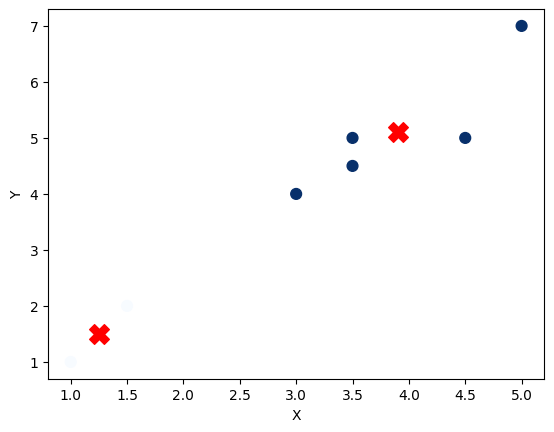

In [24]:
plt.scatter(X[:, 0],X[:, 1], c=idx, s=60, cmap='Blues')
plt.scatter(final_centroids[:,0],final_centroids[:,1],marker='X',color='red',s=200)

plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## Elbow method

In [25]:
costs = []

for K in range(2, 5):

  # randomly selects K unique indices from a dataset X without replacement, i.e., no single index will be chosen more than once
  random_indices = np.random.choice(len(X), K, replace=False)

  # extract those points as centroids
  initial = X[random_indices]

  # get final centroids from K-Means
  centroids, idx = run_kmeans(X, initial, 200)

  # compute final cost between every point and its assigned centroid
  cost = compute_cost(X, idx, centroids)

  costs.append(cost)

In [26]:
print(costs)

[np.float64(1.2178571428571427), np.float64(0.4880952380952381), np.float64(0.20833333333333331)]


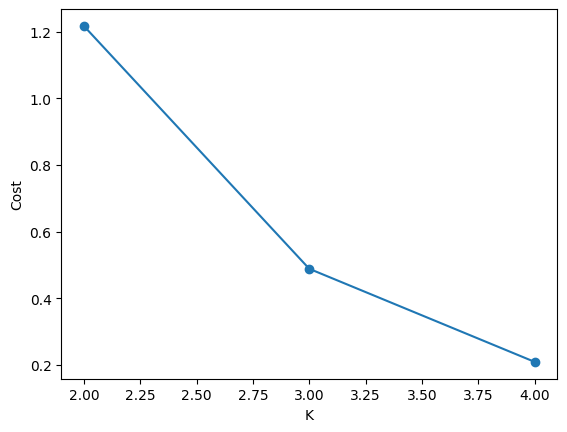

In [27]:
plt.plot(range(2, 5), costs, marker='o')
plt.xlabel("K")
plt.ylabel("Cost")
plt.show()